# Week 05: The 2D Wing — Connecting Shape to Amplitude

In the previous two weeks you built a statistical description of the *shape* of a solar butterfly wing: the mean emergence latitude drifts equatorward following a universal exponential, and the spread σ around that mean follows a piecewise-linear function of mean latitude μ. What the model is still missing is any connection to how *strong* a cycle is. A weak cycle and a strong cycle can share the same geometric skeleton — what distinguishes them is the overall level of activity.

This notebook completes the picture in two stages. **Sections 1–5** recap and finalize the shape model from Week 04, producing its key result: a universal equatorward line in σ(μ) space that is shared by every hemisphere-cycle, plus a per-cycle poleward slope that captures each cycle's individual character. **Tasks 17–20** ask you to bring in a new ingredient — total sunspot area — and find quantitative relationships between cycle amplitude and the three shape parameters, ultimately synthesizing a full 2D butterfly wing from a single input number.

**By the end of this notebook you should be able to:**
- Explain what the universal equatorward line in σ(μ) space represents physically.
- Compute the peak amplitude of each hemispheric solar cycle from the sunspot area record.
- Describe quantitative relationships between cycle amplitude and the wing shape parameters (μ₀, μ_peak, m_i).
- Generate a synthetic butterfly wing for a chosen cycle and compare it to real data.

In [1]:
import os, subprocess, sys

# Keep this path if working in Colab
repo_path = "/content/butterflai"

# Use this path if working locally
# repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()

  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 1) Load data

We work with the same composite catalog of daily sunspot group measurements used in Weeks 03 and 04. Each row records one sunspot group observation: its date, heliographic latitude, and corrected area in millionths of a solar hemisphere (MSH). We add convenience columns for hemisphere, absolute latitude, and decimal year that all subsequent sections depend on.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit, minimize_scalar, minimize

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)
df = df[df["latitude"].notna()].copy()

df["hemisphere"]   = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
df["abs_latitude"] = df["latitude"].abs()
df["year"] = df["date"].dt.year
df["decimal_year"] = df["date"].dt.year + df["date"].dt.dayofyear / 365.25

df.head()

/tmp/ipykernel_28799/1082563259.py:11: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_28799/1082563259.py:11: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,hour,minute,second,latitude,longitude,correctedArea,CAUnc,uniqueID,CYCLE,survey,hemisphere,abs_latitude,year,decimal_year
0,1825-11-05,12.0,30.0,0.0,-1.2,331.8,2120.0,570.0,101.0,NaN,1.0,south,1.2,1825,1825.845996
3,1825-11-08,12.0,0.0,0.0,-17.9,321.8,670.0,190.0,102.0,NaN,1.0,south,17.9,1825,1825.854209
4,1825-11-09,14.0,45.0,0.0,-14.6,320.7,500.0,150.0,102.0,NaN,1.0,south,14.6,1825,1825.856947
5,1825-11-10,12.0,0.0,0.0,-27.4,318.1,520.0,150.0,103.0,NaN,1.0,south,27.4,1825,1825.859685
6,1825-11-11,12.0,0.0,0.0,-26.3,320.8,470.0,140.0,103.0,NaN,1.0,south,26.3,1825,1825.862423


## 2) Standardize time: align cycles at the 15° crossing (τ)

Solar cycles don't start on the same calendar date and don't last the same length of time, so we can't compare them on a shared time axis without first choosing a common reference point. The anchor we use is the moment when the **yearly mean absolute emergence latitude crosses 15° on its way equatorward** — a latitude that falls reliably in the well-observed middle of every cycle.

For each (cycle, hemisphere) pair we find that crossing by linear interpolation between the last year the mean sits above 15° and the first year it falls below. The shifted coordinate **τ = decimal\_year − t₀** is in physical units (years) and places all cycles on the same footing regardless of when they actually occurred.

In [3]:
t0_lookup = {}
for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
    yearly_mean = group.groupby("year")["abs_latitude"].mean().sort_index()
    years, means = yearly_mean.index.values, yearly_mean.values
    below = means < 15.0
    if not below.any() or below.all():
        continue
    idx1 = np.argmax(below)
    if idx1 == 0:
        continue
    y0, mu0 = years[idx1 - 1], means[idx1 - 1]
    y1, mu1 = years[idx1],     means[idx1]
    t0_lookup[(cyc, hemi)] = y0 + (15.0 - mu0) / (mu1 - mu0)

df["t0"]  = df.apply(lambda r: t0_lookup.get((r["CYCLE"], r["hemisphere"]), np.nan), axis=1)
df["tau"] = df["decimal_year"] - df["t0"]

## 3) Fit a universal mean path μ(τ) and refine the time origin

The equatorward drift of the mean emergence latitude follows an exponential decay:

$$\mu(\tau) = a \, e^{-\tau / b}$$

where **a** is the mean latitude at τ = 0 and **b** is the e-folding timescale — the number of years it takes the mean to drop by a factor of e ≈ 2.7. In Week 04 you found that the best-fit (a, b) is nearly the same for every cycle, so here we fit it once, globally, by pooling binned (τ, μ) measurements from all hemisphere-cycles.

With the universal (a, b) in hand we can refine each cycle's t₀: a small time shift Δt is found for each hemisphere-cycle that minimises its residuals against the common template. The refined coordinate **τ_refined** gives a tighter alignment than the raw 15° crossing, because it uses the full shape of the wing rather than a single crossing point.

In [4]:
def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

N_BINS_13   = 20
cycles_13   = [c for c in sorted(df["CYCLE"].dropna().unique()) if c >= 12]
cmap_13     = cm.get_cmap("tab20", len(cycles_13))
cyc_idx_13  = {c: i for i, c in enumerate(cycles_13)}

all_tau_bins, all_mu_bins = [], []
hemicycle_bins_13 = {}

for cyc in cycles_13:
    for hemi in ["north", "south"]:
        if (cyc, hemi) not in t0_lookup:
            continue
        mask   = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau"].notna()
        df_sel = df[mask]
        if len(df_sel) < 50:
            continue
        t_min, t_max = df_sel["tau"].min(), df_sel["tau"].max()
        bins        = np.linspace(t_min, t_max, N_BINS_13 + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bt, bm = [], []
        for i in range(N_BINS_13):
            lats_bin = df_sel.loc[
                (df_sel["tau"] >= bins[i]) & (df_sel["tau"] < bins[i + 1]),
                "abs_latitude"].values
            if len(lats_bin) < 10:
                continue
            mu_f, _ = sp_norm.fit(lats_bin)
            bt.append(bin_centers[i]); bm.append(mu_f)
        if len(bt) < 5:
            continue
        bt = np.array(bt); bm = np.array(bm)
        hemicycle_bins_13[(cyc, hemi)] = (bt, bm)
        all_tau_bins.extend(bt); all_mu_bins.extend(bm)

popt_global, _ = curve_fit(exp_decay, all_tau_bins, all_mu_bins, p0=[15.0, 5.0])
a_mu_univ, b_mu_univ = popt_global
print(f"Universal μ(τ):  a = {a_mu_univ:.2f}°   b = {b_mu_univ:.2f} yr")

# Refine t₀ per hemisphere-cycle
t0_refined = {}
for (cyc, hemi), (bt, bm) in hemicycle_bins_13.items():
    def _res(dt, _bt=bt, _bm=bm):
        return np.sum((_bm - exp_decay(_bt - dt, a_mu_univ, b_mu_univ)) ** 2)
    res = minimize_scalar(_res, bounds=(-4, 4), method="bounded")
    t0_refined[(cyc, hemi)] = t0_lookup[(cyc, hemi)] + res.x

df["t0_refined"]  = df.apply(lambda r: t0_refined.get((r["CYCLE"], r["hemisphere"]), np.nan), axis=1)
df["tau_refined"] = df["decimal_year"] - df["t0_refined"]

/tmp/ipykernel_28799/1516041124.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_13     = cm.get_cmap("tab20", len(cycles_13))


Universal μ(τ):  a = 16.45°   b = 8.14 yr


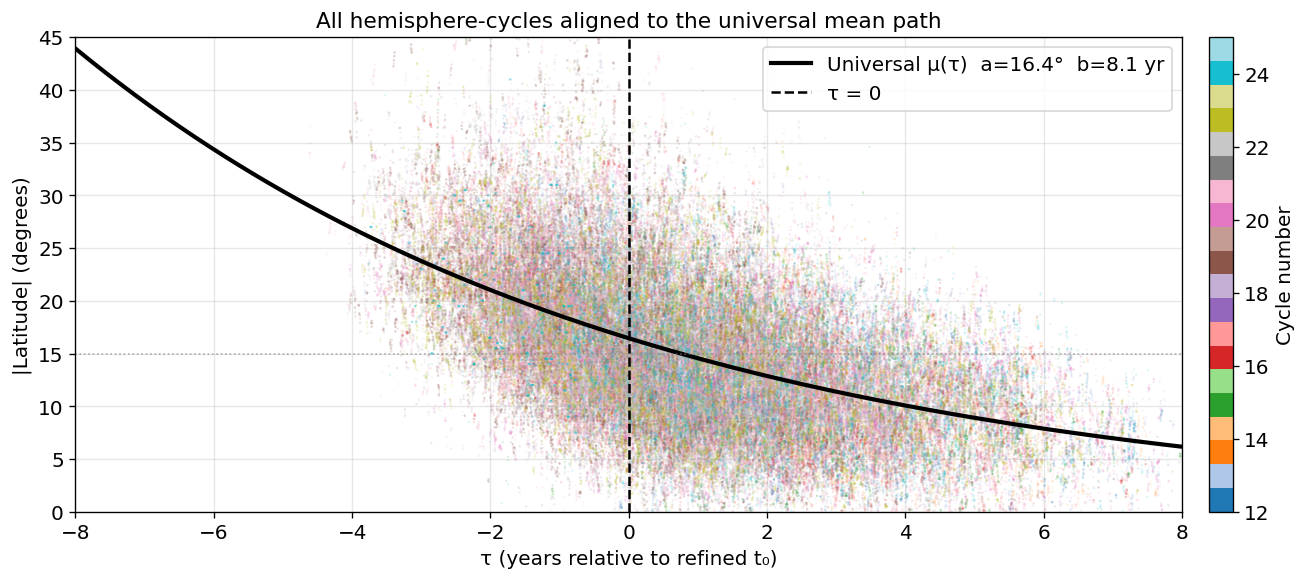

In [5]:
TAU_GRID_13 = np.linspace(-8, 8, 300)

# Plot 1: All hemisphere-cycles aligned to the universal mean path
fig1, ax1 = plt.subplots(figsize=(12, 5))
for (cyc, hemi) in hemicycle_bins_13:
    mask = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau_refined"].notna()
    grp  = df[mask]
    ax1.scatter(grp["tau_refined"], grp["abs_latitude"],
                s=2, color=cmap_13(cyc_idx_13[cyc]), alpha=0.15, edgecolors="none")
ax1.plot(TAU_GRID_13, exp_decay(TAU_GRID_13, a_mu_univ, b_mu_univ),
         color="black", linewidth=2.5,
         label=f"Universal μ(τ)  a={a_mu_univ:.1f}°  b={b_mu_univ:.1f} yr")
ax1.axvline(0, color="black", linewidth=1.5, linestyle="--", label="τ = 0")
ax1.axhline(15, color="gray", linewidth=1, linestyle=":", alpha=0.6)
ax1.set_xlabel("τ (years relative to refined t₀)")
ax1.set_ylabel("|Latitude| (degrees)")
ax1.set_title("All hemisphere-cycles aligned to the universal mean path")
ax1.set_ylim(0, 45); ax1.set_xlim(-8, 8)
ax1.legend(loc="upper right")
sm1 = plt.cm.ScalarMappable(cmap="tab20",
                              norm=plt.Normalize(vmin=min(cycles_13), vmax=max(cycles_13)))
sm1.set_array([])
fig1.colorbar(sm1, ax=ax1, pad=0.02, label="Cycle number")
plt.tight_layout()
plt.show()


## 4) Model σ(μ): spread as a function of mean latitude

Rather than tracking the spread σ as a function of time, we describe it as a function of the **current mean emergence latitude** μ. This is more natural physically: two cycles at the same latitude should have similar spreads regardless of their absolute timing, because the spread is determined by the state of the dynamo, not by the calendar.

The spread is not monotonic in μ. At high latitudes (early in the cycle) there are few sunspots so the spread appears narrow; at low latitudes (late in the cycle) the active zone has collapsed toward the equator and is narrow again. The maximum spread occurs somewhere in between, at a characteristic mid-cycle latitude μ_peak. This bell-shaped behaviour in μ-space is captured by a **split Gaussian**:

$$\sigma(\mu) = A \exp\!\left(-\frac{(\mu - \mu_{\mathrm{peak}})^2}{2 s_{L,R}^2}\right)$$

where $s_L$ governs the poleward side (large μ, early cycle) and $s_R$ governs the equatorward side (small μ, late cycle). When $s_L \neq s_R$ the envelope is asymmetric — which is what the data show.

In [6]:
def split_normal_mu(mu, A, mu_peak, s_L, s_R):
    return np.where(
        mu >= mu_peak,
        A * np.exp(-0.5 * ((mu - mu_peak) / s_L) ** 2),
        A * np.exp(-0.5 * ((mu - mu_peak) / s_R) ** 2),
    )

N_BINS_15 = 20
MU_GRID   = np.linspace(2, 42, 300)
results_15 = []

for cyc in cycles_13:
    for hemi in ["north", "south"]:
        if (cyc, hemi) not in t0_refined:
            continue
        mask   = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau_refined"].notna()
        df_sel = df[mask]
        if len(df_sel) < 50:
            continue
        t_min, t_max = df_sel["tau_refined"].min(), df_sel["tau_refined"].max()
        bins        = np.linspace(t_min, t_max, N_BINS_15 + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bm_list, bs_list = [], []
        for i in range(N_BINS_15):
            lats_bin = df_sel.loc[
                (df_sel["tau_refined"] >= bins[i]) & (df_sel["tau_refined"] < bins[i + 1]),
                "abs_latitude"].values
            if len(lats_bin) < 10:
                continue
            mu_f, sigma_f = sp_norm.fit(lats_bin)
            bm_list.append(mu_f); bs_list.append(sigma_f)
        if len(bm_list) < 5:
            continue
        bm_arr = np.array(bm_list); bs_arr = np.array(bs_list)
        sidx = np.argsort(bm_arr)
        bm_arr, bs_arr = bm_arr[sidx], bs_arr[sidx]
        try:
            p0 = [bs_arr.max(), bm_arr[np.argmax(bs_arr)], 5.0, 4.0]
            popt, _ = curve_fit(split_normal_mu, bm_arr, bs_arr, p0=p0, maxfev=10_000)
            A_f, mu_peak_f, sL_f, sR_f = popt
        except RuntimeError:
            continue
        if not (0.5 < A_f < 20 and 2 < mu_peak_f < 38 and 0.5 < sL_f < 20 and 0.5 < sR_f < 20):
            continue
        results_15.append(dict(
            cycle=cyc, hemisphere=hemi,
            A=A_f, mu_peak=mu_peak_f, sL=sL_f, sR=sR_f,
            sigma_curve=split_normal_mu(MU_GRID, A_f, mu_peak_f, sL_f, sR_f),
            bin_mu=bm_arr, bin_sigma=bs_arr,
        ))

print(f"Fitted {len(results_15)} hemisphere-cycles.")

Fitted 19 hemisphere-cycles.


## 5) Universal piecewise-linear envelope

The key insight from Week 04 is that the equatorward half of every σ(μ) curve — the side where spots are migrating toward the equator — falls on **the same straight line** regardless of which cycle you look at. This universality tells us something deep: the process that narrows the active zone as the cycle approaches minimum is the same in every cycle. One slope and one intercept describe it for all of them.

The poleward half, by contrast, is cycle-specific: stronger cycles detach from the shared line at a higher latitude and descend more steeply. We encode this with a piecewise-linear model fitted *jointly* across all hemisphere-cycles:

$$\sigma(\mu) = \begin{cases} m_{\text{shared}}\,\mu + b_{\text{shared}} & \mu \le \mu_{\text{peak},i} \quad \text{(universal — same for all cycles)} \\ m_i\,\mu + b_i & \mu > \mu_{\text{peak},i} \quad \text{(per-cycle)} \end{cases}$$

Continuity at the detachment latitude $\mu_{\text{peak},i}$ determines $b_i$ automatically, so the model needs only two universal numbers $(m_{\text{shared}},\, b_{\text{shared}})$ and two per-cycle numbers $(\mu_{\text{peak},i},\, m_i)$ to fully describe each wing's spread profile. In the exercises below you will connect those per-cycle numbers to the overall strength of each cycle.

Universal line:  σ(μ) = 0.4076·μ + 0.2507
Zero crossing at μ = -0.62°
RMSE — split-normal independent : 0.738°
RMSE — piecewise-linear joint   : 0.805°  (+9.1%)


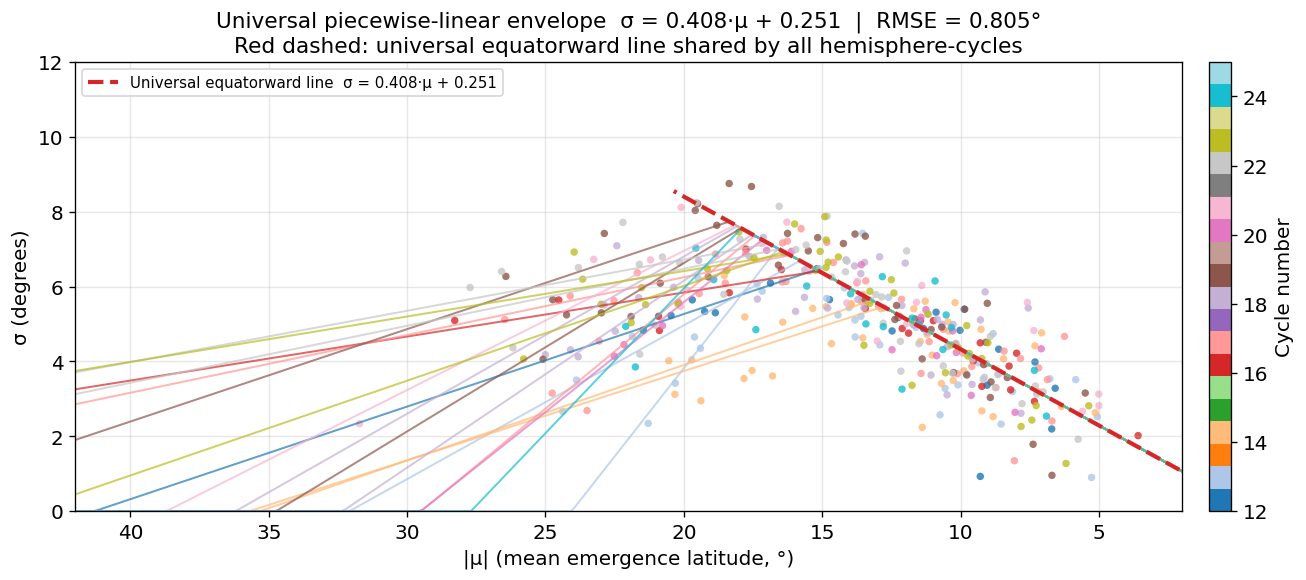


Per-cycle variability:
  μ_peak : 16.50° ± 1.52°  ← detachment latitude
  σ_peak : 6.98° ± 0.62°  ← derived amplitude
  m_i  : -0.3678 ± 0.2260  ← per-cycle poleward slope


In [7]:
def piecewise_linear_wing(mu, m_shared, b_shared, mu_peak, m_i):
    """Universal equatorward line + per-cycle poleward line, joined continuously at mu_peak."""
    sigma_peak = m_shared * mu_peak + b_shared
    b_per = sigma_peak - m_i * mu_peak
    return np.clip(
        np.where(mu <= mu_peak, m_shared * mu + b_shared, m_i * mu + b_per),
        0.0, None
    )

# Bootstrap: fit the shared equatorward line from pooled equatorward-side points
eq_mu, eq_sigma = [], []
for r in results_15:
    mask = r["bin_mu"] <= r["mu_peak"]
    eq_mu.extend(r["bin_mu"][mask]); eq_sigma.extend(r["bin_sigma"][mask])
m_init, b_init = np.polyfit(eq_mu, eq_sigma, 1)
m_i_init = np.mean([-r["A"] / (2 * max(r["sL"], 1.0)) for r in results_15])

# Joint L-BFGS-B optimisation
n_hc = len(results_15)

def residuals_pl(x):
    m_sh, b_sh = x[0], x[1]
    return sum(
        np.sum((r["bin_sigma"] - piecewise_linear_wing(
            r["bin_mu"], m_sh, b_sh, x[2 + 2*i], x[3 + 2*i])) ** 2)
        for i, r in enumerate(results_15)
    )

x0 = np.array([m_init, b_init] + [val for r in results_15
                                   for val in (r["mu_peak"], m_i_init)])
bounds = list(zip(
    [0.0, -5.0] + [2.0, -5.0] * n_hc,
    [2.0,  5.0] + [38.0, 0.0] * n_hc,
))
opt = minimize(residuals_pl, x0, method="L-BFGS-B", bounds=bounds)

m_shared_fit, b_shared_fit = opt.x[0], opt.x[1]
print(f"Universal line:  σ(μ) = {m_shared_fit:.4f}·μ + {b_shared_fit:.4f}")
print(f"Zero crossing at μ = {-b_shared_fit / m_shared_fit:.2f}°")

# Reconstruct per-cycle fitted curves
MU_GRID_PL = np.linspace(2, 42, 300)
results_pl = []
for i, r in enumerate(results_15):
    mu_peak_i    = opt.x[2 + 2*i]
    m_i          = opt.x[3 + 2*i]
    sigma_peak_i = m_shared_fit * mu_peak_i + b_shared_fit
    results_pl.append(dict(
        cycle=r["cycle"], hemisphere=r["hemisphere"],
        m_shared=m_shared_fit, b_shared=b_shared_fit,
        mu_peak=mu_peak_i, m_i=m_i, sigma_peak=sigma_peak_i,
        sigma_curve=piecewise_linear_wing(
            MU_GRID_PL, m_shared_fit, b_shared_fit, mu_peak_i, m_i),
        bin_mu=r["bin_mu"], bin_sigma=r["bin_sigma"],
    ))

# RMSE comparison
def rmse_sn(res_list):
    return np.sqrt(np.mean([
        np.mean((r["bin_sigma"] - split_normal_mu(
            r["bin_mu"], r["A"], r["mu_peak"], r["sL"], r["sR"])) ** 2)
        for r in res_list
    ]))

def rmse_pl(res_list):
    return np.sqrt(np.mean([
        np.mean((r["bin_sigma"] - piecewise_linear_wing(
            r["bin_mu"], r["m_shared"], r["b_shared"], r["mu_peak"], r["m_i"])) ** 2)
        for r in res_list
    ]))

rmse_15 = rmse_sn(results_15)
rmse_16 = rmse_pl(results_pl)
print(f"RMSE — split-normal independent : {rmse_15:.3f}°")
print(f"RMSE — piecewise-linear joint   : {rmse_16:.3f}°  ({(rmse_16 - rmse_15)/rmse_15*100:+.1f}%)")

# ── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for r in results_pl:
    c = cmap_13(cyc_idx_13.get(r["cycle"], 0))
    ax.scatter(r["bin_mu"], r["bin_sigma"], s=20, color=c,
               alpha=0.8, edgecolors="none", zorder=1)
    ax.plot(MU_GRID_PL, r["sigma_curve"], color=c,
            linewidth=1.2, alpha=0.7, zorder=2)

mu_eq = np.linspace(0, max(r["mu_peak"] for r in results_pl) + 2, 200)
ax.plot(mu_eq, np.clip(m_shared_fit * mu_eq + b_shared_fit, 0, None),
        color="tab:red", linewidth=2.5, linestyle="--",
        label=f"Universal equatorward line  σ = {m_shared_fit:.3f}·μ + {b_shared_fit:.3f}",
        zorder=5)

ax.invert_xaxis()
ax.set_xlim(42, 2)
ax.set_ylim(0, 12)
ax.set_xlabel("|μ| (mean emergence latitude, °)")
ax.set_ylabel("σ (degrees)")
ax.set_title(
    f"Universal piecewise-linear envelope  "
    f"σ = {m_shared_fit:.3f}·μ + {b_shared_fit:.3f}  |  RMSE = {rmse_16:.3f}°\n"
    "Red dashed: universal equatorward line shared by all hemisphere-cycles"
)
ax.legend(loc="upper left", fontsize=9)

sm = plt.cm.ScalarMappable(cmap="tab20",
                            norm=plt.Normalize(vmin=min(cycles_13), vmax=max(cycles_13)))
sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.02, label="Cycle number")
plt.tight_layout()
plt.show()

# Numeric summary
mu_peaks  = [r["mu_peak"]    for r in results_pl]
sig_peaks = [r["sigma_peak"] for r in results_pl]
m_is    = [r["m_i"]      for r in results_pl]
print(f"\nPer-cycle variability:")
print(f"  μ_peak : {np.mean(mu_peaks):.2f}° ± {np.std(mu_peaks):.2f}°  ← detachment latitude")
print(f"  σ_peak : {np.mean(sig_peaks):.2f}° ± {np.std(sig_peaks):.2f}°  ← derived amplitude")
print(f"  m_i  : {np.mean(m_is):.4f} ± {np.std(m_is):.4f}  ← per-cycle poleward slope")

---
## Week 05 Exercises: From Wing Shape to a Full Synthetic Cycle

Sections 1–5 give you the geometric skeleton of a butterfly wing. The exercises below ask you to attach one more piece: the **amplitude** of the solar cycle. A cycle's amplitude tells you how active it was — how many sunspots appeared, how large they were, how long the active zone persisted. Once you can predict the wing's shape parameters from its amplitude, you can synthesize a complete 2D wing from a single number.

The four tasks build up to that synthesis step by step.

---

## Task 17 — Solar Cycle Amplitude from Total Sunspot Area

The standard proxy for solar cycle strength is the **total daily corrected sunspot area** — the sum of all individual sunspot group areas on a given day, measured in millionths of a solar hemisphere (MSH). Plotted over time, this quantity rises and falls with each ~11-year cycle, with strong cycles reaching much higher peaks than weak ones.

Raw daily values are noisy (individual sunspot groups appear and disappear), so we smooth with a rolling average before looking for cycle peaks.

**Tasks:**
- For each hemisphere separately, compute the total daily corrected area. Include only sunspot groups with a corrected area **greater than 50 MSH** — smaller features are at the noise floor of the older observations.
- Apply rolling averages with windows of **3, 6, 12, and 24 months**. Plot all four smoothed curves on the same axes for each hemisphere.
- Focus on **cycles 12 and later**. Earlier data come from heterogeneous sources with different calibration standards, making direct amplitude comparisons unreliable.

Which smoothing window best captures the large-scale rise-and-fall of each cycle without washing out differences between strong and weak cycles?

In [8]:
df.head()

,date,hour,minute,second,latitude,longitude,correctedArea,CAUnc,uniqueID,CYCLE,survey,hemisphere,abs_latitude,year,decimal_year,t0,tau,t0_refined,tau_refined
0,1825-11-05,12.0,30.0,0.0,-1.2,331.8,2120.0,570.0,101.0,NaN,1.0,south,1.2,1825,1825.845996,NaN,NaN,NaN,NaN
3,1825-11-08,12.0,0.0,0.0,-17.9,321.8,670.0,190.0,102.0,NaN,1.0,south,17.9,1825,1825.854209,NaN,NaN,NaN,NaN
4,1825-11-09,14.0,45.0,0.0,-14.6,320.7,500.0,150.0,102.0,NaN,1.0,south,14.6,1825,1825.856947,NaN,NaN,NaN,NaN
5,1825-11-10,12.0,0.0,0.0,-27.4,318.1,520.0,150.0,103.0,NaN,1.0,south,27.4,1825,1825.859685,NaN,NaN,NaN,NaN
6,1825-11-11,12.0,0.0,0.0,-26.3,320.8,470.0,140.0,103.0,NaN,1.0,south,26.3,1825,1825.862423,NaN,NaN,NaN,NaN


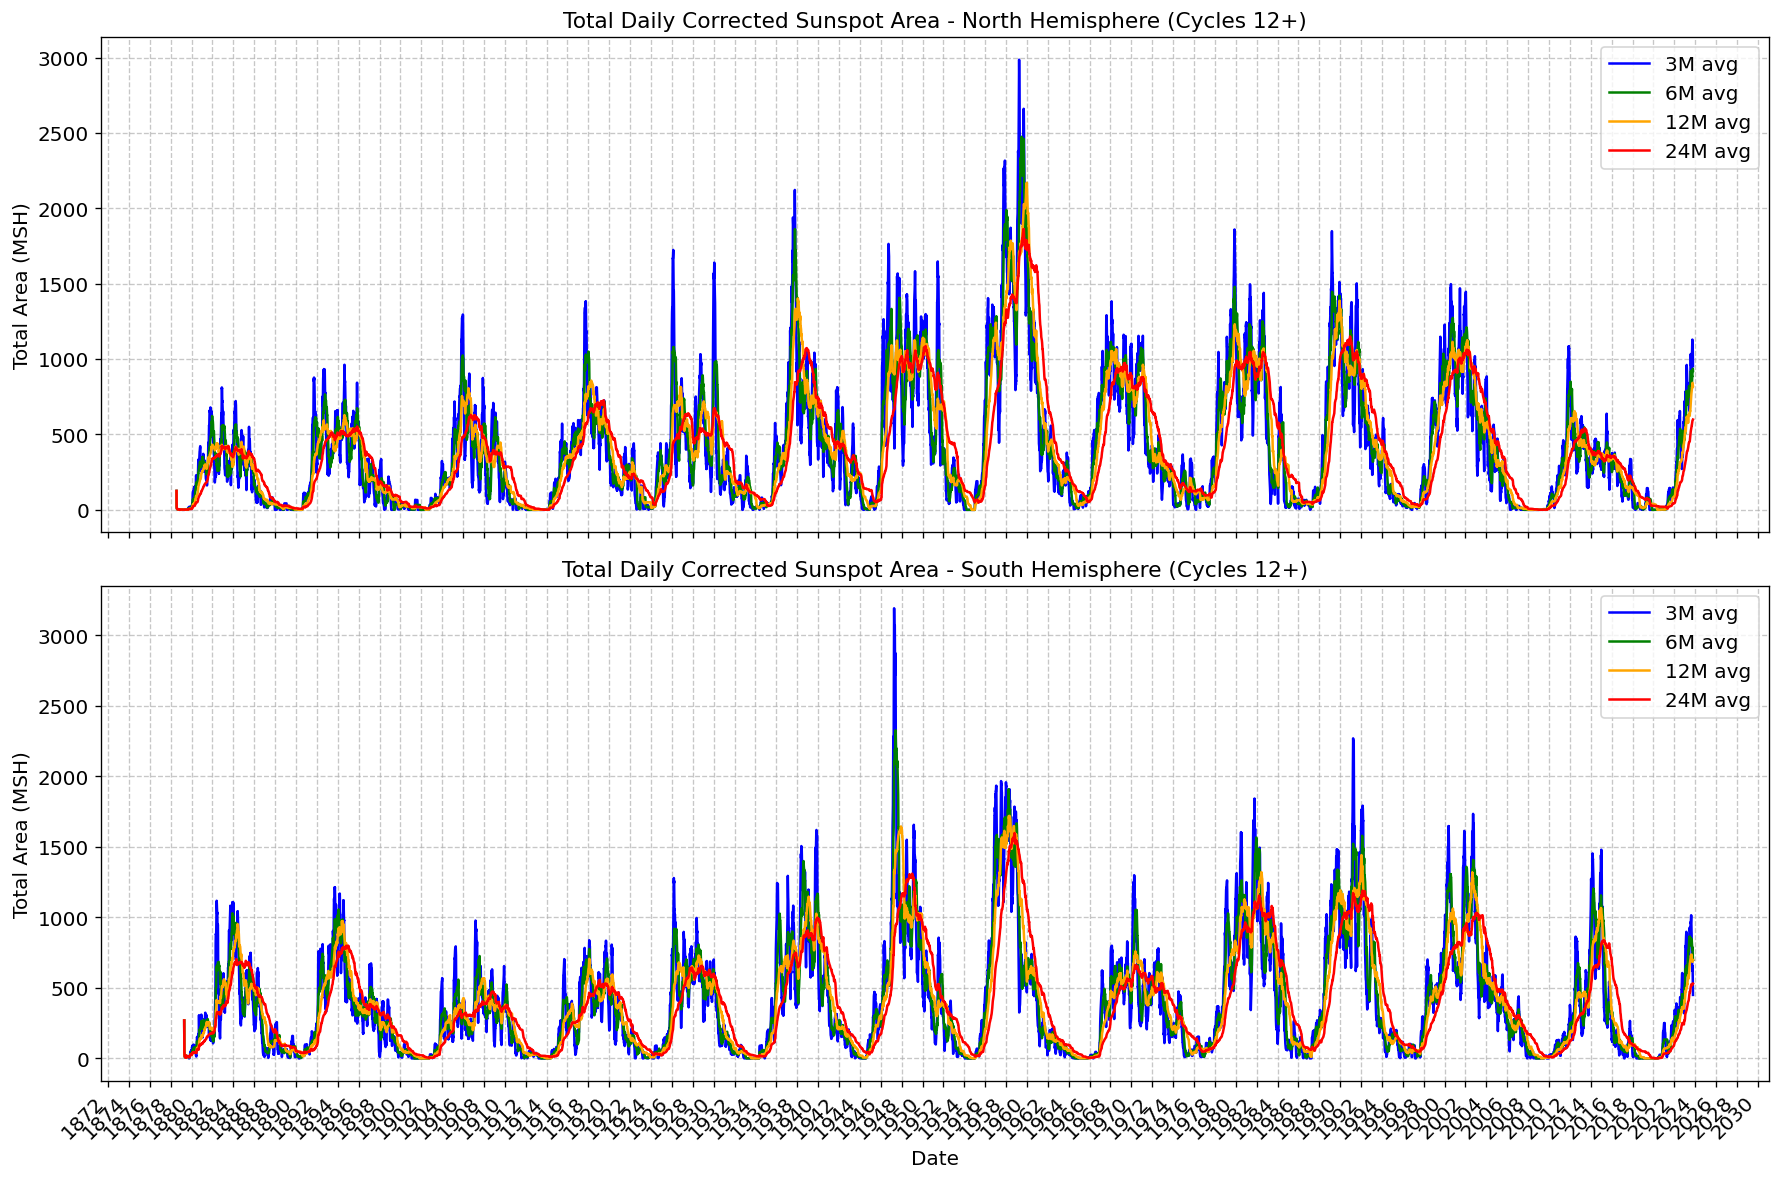

In [16]:
# Put your code for Task 17 here

import matplotlib.dates as mdates

# 1. Filter the original dataframe for relevant cycles and corrected area > 50 MSH
filtered_df = df.dropna(subset=["CYCLE"]).copy()
filtered_df = filtered_df[filtered_df["CYCLE"] >= 12]
filtered_df = filtered_df[filtered_df["correctedArea"] > 50]

# 2. Set 'date' as index and compute total daily corrected area per hemisphere
# Ensure 'date' is a proper datetime index for resampling
filtered_df['date'] = pd.to_datetime(filtered_df['date'])
filtered_df = filtered_df.set_index('date')

# Dictionary to store daily total area and smoothed data for each hemisphere
hemisphere_data = {}

# Define rolling window sizes in days (approximate for months)
window_sizes = {
    '3M': '90D',
    '6M': '180D',
    '12M': '365D',
    '24M': '730D'
}

print("Collecting and smoothing data for each hemisphere...")

for hemi in ["north", "south"]:
    hemi_df = filtered_df[filtered_df["hemisphere"] == hemi]

    # Compute total daily corrected area for the current hemisphere
    daily_total_area = hemi_df["correctedArea"].resample('D').sum()

    # Fill any missing days with 0 (since no sunspots means 0 area)
    daily_total_area = daily_total_area.fillna(0)

    # Apply rolling averages
    smoothed_data = {
        'daily_total': daily_total_area
    }
    for label, window_str in window_sizes.items():
        smoothed_data[label] = daily_total_area.rolling(window=window_str, min_periods=1).mean()

    hemisphere_data[hemi] = smoothed_data

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

colors = {'3M': 'blue', '6M': 'green', '12M': 'orange', '24M': 'red'}

for i, hemi in enumerate(["north", "south"]):
    ax = axes[i]
    data = hemisphere_data[hemi]
    for label, color in colors.items():
        ax.plot(data[label], color=color, label=f'{label} avg')

    ax.set_title(f'Total Daily Corrected Sunspot Area - {hemi.capitalize()} Hemisphere (Cycles 12+)')
    ax.set_ylabel('Total Area (MSH)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

# Format x-axis dates
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2)) # Show every 2 years
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()


## Task 18 — Peak Amplitude and Timing of Each Hemispheric Cycle

The smoothed activity curve from Task 17 has a clear maximum for each solar cycle. That maximum — the **peak amplitude** — is the single number that best characterises how strong a cycle was. Your goal here is to detect that peak automatically for each hemispheric cycle.

**Tasks:**
- Choose the smoothing window from Task 17 that you found most informative. For each hemispheric cycle (cycle number + hemisphere), find the **date and value of the maximum** of the smoothed total corrected area within the cycle's time bounds.
- Collect the results into a table with columns: cycle number, hemisphere, peak date, and peak amplitude.
- Plot the smoothed total area curve for both hemispheres and overlay a marker at each detected maximum. Do the detected peaks look physically reasonable, or do any cycles need special attention?

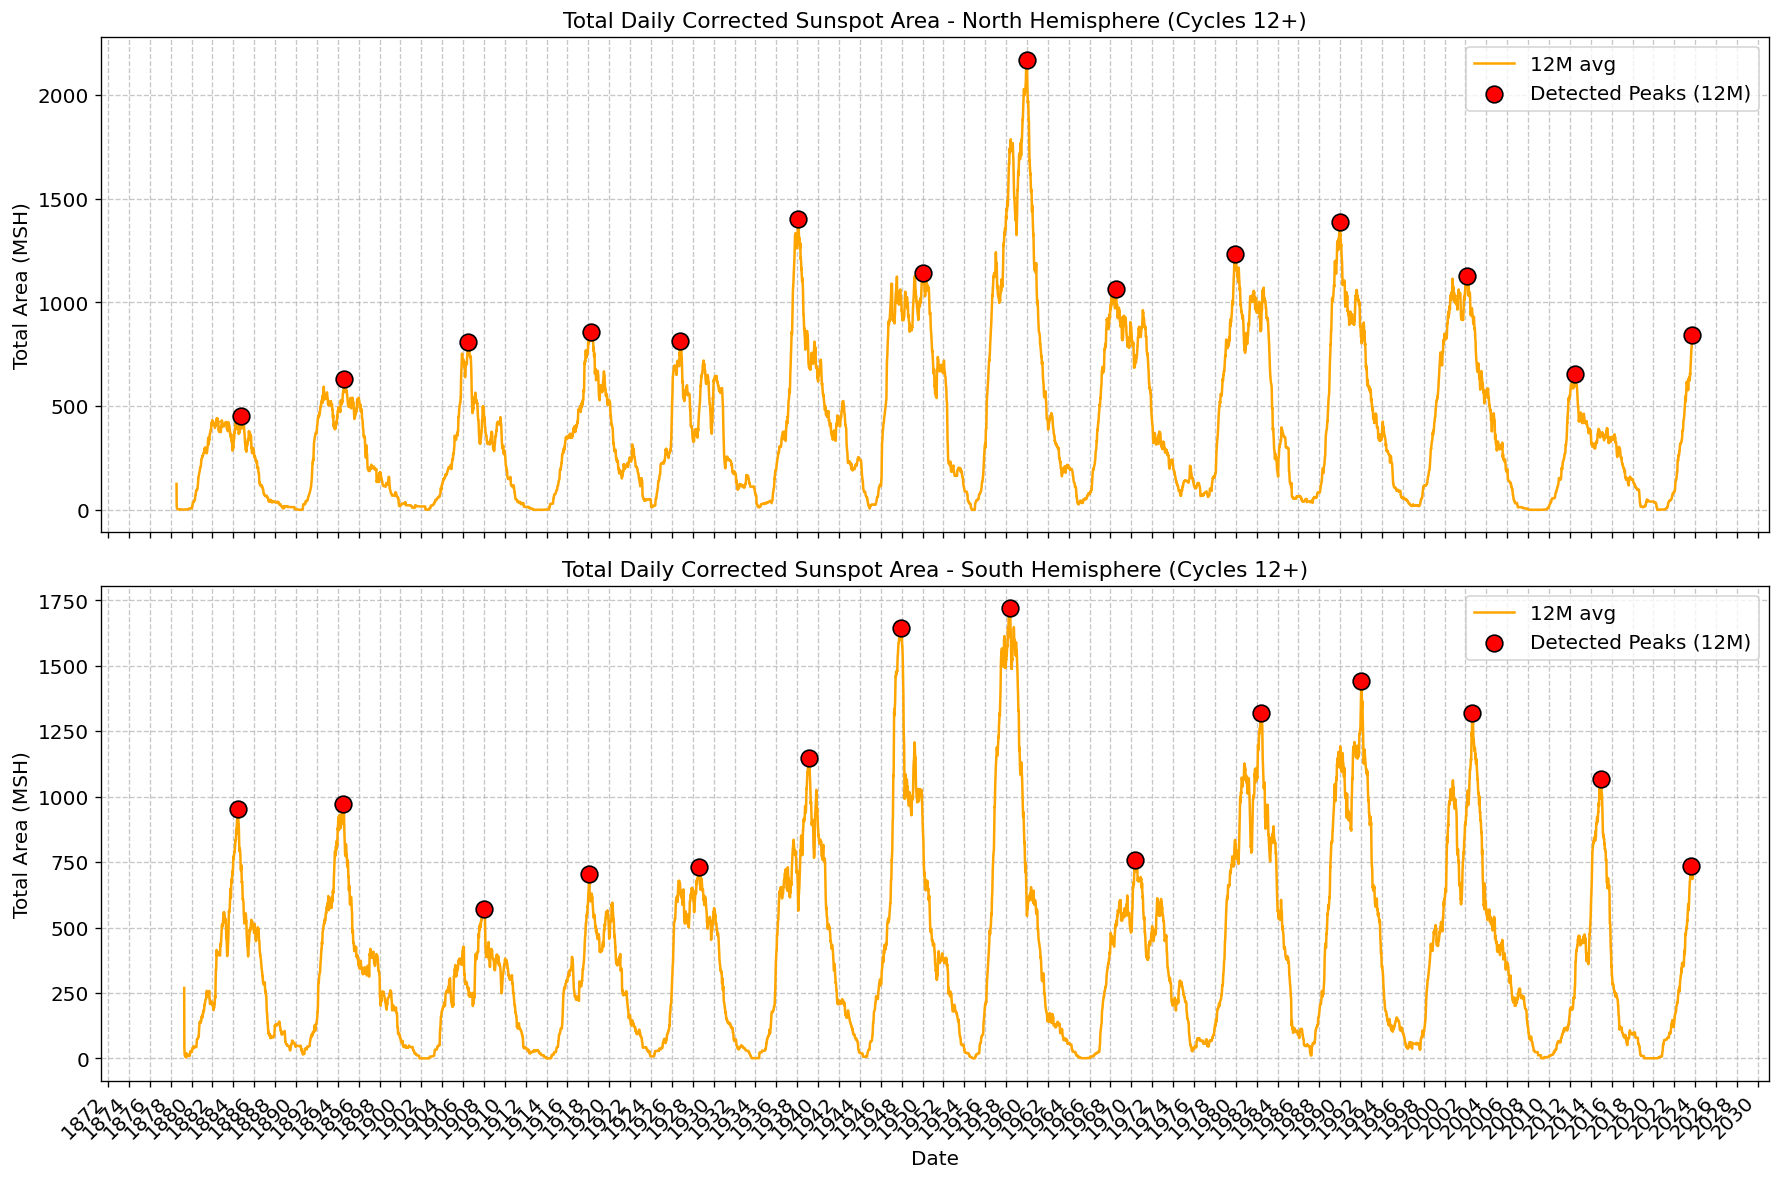

,cycle,hemisphere,peak_date,peak_amplitude
0,12.0,north,1884-10-11,451.029827
1,13.0,north,1894-08-22,628.455959
2,14.0,north,1906-07-10,806.545962
3,15.0,north,1918-04-11,857.300953
4,16.0,north,1926-10-17,815.680616
5,17.0,north,1938-01-24,1402.176068
6,18.0,north,1950-01-15,1141.434984
7,19.0,north,1959-12-31,2169.608501
8,20.0,north,1968-07-19,1066.314219
9,21.0,north,1979-11-25,1231.057315


In [19]:
# Put your code for Task 18 here

import matplotlib.dates as mdates

# 1. Filter the original dataframe for relevant cycles and corrected area > 50 MSH
filtered_df = df.dropna(subset=["CYCLE"]).copy()
filtered_df = filtered_df[filtered_df["CYCLE"] >= 12]
filtered_df = filtered_df[filtered_df["correctedArea"] > 50]

# 2. Set 'date' as index and compute total daily corrected area per hemisphere
# Ensure 'date' is a proper datetime index for resampling
filtered_df['date'] = pd.to_datetime(filtered_df['date'])
filtered_df = filtered_df.set_index('date')

# Dictionary to store daily total area and smoothed data for each hemisphere
hemisphere_data = {}

# Define rolling window sizes in days (approximate for months)
window_sizes = {
    '3M': '90D',
    '6M': '180D',
    '12M': '365D',
    '24M': '730D'
}

print("Collecting and smoothing data for each hemisphere...")

for hemi in ["north", "south"]:
    hemi_df = filtered_df[filtered_df["hemisphere"] == hemi]

    # Compute total daily corrected area for the current hemisphere
    daily_total_area = hemi_df["correctedArea"].resample('D').sum()

    # Fill any missing days with 0 (since no sunspots means 0 area)
    daily_total_area = daily_total_area.fillna(0)

    # Apply rolling averages
    smoothed_data = {
        'daily_total': daily_total_area
    }
    for label, window_str in window_sizes.items():
        smoothed_data[label] = daily_total_area.rolling(window=window_str, min_periods=1).mean()

    hemisphere_data[hemi] = smoothed_data

# Choose the smoothing window: 12-month average
chosen_window = '12M'

# List to store peak amplitude results
peak_amplitudes_list = []

# Get unique cycles from the filtered_df
unique_cycles = sorted(filtered_df['CYCLE'].dropna().unique())

for hemi in ["north", "south"]:
    smoothed_series = hemisphere_data[hemi][chosen_window]

    for cyc in unique_cycles:
        # Determine the time boundaries for the current cycle and hemisphere
        # from the filtered_df (which contains the raw observation dates)
        cycle_hemi_df_slice = filtered_df[(filtered_df['CYCLE'] == cyc) &
                                          (filtered_df['hemisphere'] == hemi)]

        if cycle_hemi_df_slice.empty:
            continue

        cycle_start_date = cycle_hemi_df_slice.index.min()
        cycle_end_date = cycle_hemi_df_slice.index.max()

        # Filter the smoothed series for the specific cycle's duration
        cycle_smoothed_area = smoothed_series.loc[cycle_start_date:cycle_end_date]

        if not cycle_smoothed_area.empty:
            peak_val = cycle_smoothed_area.max()
            peak_date = cycle_smoothed_area.idxmax()

            peak_amplitudes_list.append({
                'cycle': cyc,
                'hemisphere': hemi,
                'peak_date': peak_date,
                'peak_amplitude': peak_val
            })

df_peak_amplitudes = pd.DataFrame(peak_amplitudes_list)

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

colors = {chosen_window: 'orange'} # Only plot the chosen window

for i, hemi in enumerate(["north", "south"]):
    ax = axes[i]
    data = hemisphere_data[hemi]

    # Plot the smoothed curve for the chosen window
    ax.plot(data[chosen_window], color=colors[chosen_window], label=f'{chosen_window} avg')

    # Plot the detected peak markers
    hemi_peaks = df_peak_amplitudes[df_peak_amplitudes['hemisphere'] == hemi]
    ax.scatter(hemi_peaks['peak_date'],
               hemi_peaks['peak_amplitude'],
               color='red', # Use a distinct color for markers
               marker='o',
               s=100, # Larger size for visibility
               edgecolors='black',
               label=f'Detected Peaks ({chosen_window})',
               zorder=5) # Ensure markers are on top

    ax.set_title(f'Total Daily Corrected Sunspot Area - {hemi.capitalize()} Hemisphere (Cycles 12+)')
    ax.set_ylabel('Total Area (MSH)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

# Format x-axis dates
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2)) # Show every 2 years
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Display the table of peak amplitudes
display(df_peak_amplitudes)


## Task 19 — Relating Cycle Amplitude to Wing Shape Parameters

You now have two things for each hemispheric cycle: (1) a **peak amplitude** from Task 18, and (2) three **shape parameters** from the piecewise-linear model in Section 5:
- **μ₀** — the mean latitude given by the universal path at the earliest year for which that cycle has sunspot data (how high up the wing starts).
- **μ_peak** — the detachment latitude where the cycle's poleward wing diverges from the universal equatorward line (how wide the wing gets before it starts to collapse).
- **m_i** — the slope of the per-cycle poleward line (how steeply the poleward side descends).

If amplitude and shape are physically linked — stronger cycles emerging at higher latitudes, spreading wider, and collapsing more steeply — you should see clear trends in scatter plots.

**Tasks:**

1. **Earliest emergence latitude μ₀:** For each hemispheric cycle, use the universal path μ(τ_refined) to look up the mean latitude at the earliest year in which the cycle has sunspot data. Plot μ₀ versus peak amplitude and fit a curve. Does a stronger cycle start at a higher latitude?

2. **Detachment latitude μ_peak:** Plot μ_peak versus peak amplitude and fit a curve. Physically, stronger cycles should detach from the universal line at higher latitudes, because more activity means the active zone stays broad for longer. Do the data support this?

3. **Poleward slope m_i:** Plot m_i versus peak amplitude and fit a curve. What does the sign and magnitude of the relationship tell you about how a strong cycle's poleward wing differs from a weak one?

Start with a linear fit for each relationship. If the scatter looks non-linear, try a power law or an exponential.

In [ ]:
# Put your code for Task 19 here

## Task 20 — Putting It All Together: Synthesizing a Wing from Amplitude

This is the payoff task. Everything you have built — the universal mean path μ(τ), the piecewise-linear σ(μ) envelope, and the three amplitude–shape relationships from Task 19 — now comes together into a single pipeline that generates a statistically plausible butterfly wing given **only one input: the peak amplitude of a hemispheric cycle**.

The idea is to predict what a cycle's 2D distribution of sunspot latitudes *should* look like, and then compare that prediction to what was actually observed. Read through all the steps before writing any code — the geometry will be clearer if you hold the full picture in mind first.

1. Pick a hemispheric cycle from the dataset (e.g., cycle 24, northern hemisphere). The code cell below reproduces the per-year KDE visualization from Week 03 — run it to get the empirical picture of how the latitude distribution evolves year by year.

In [ ]:
# Task 8: KDE evolution through a solar cycle — butterfly diagram + per-year KDE profiles
import matplotlib.dates as mdates
from scipy.stats import gaussian_kde

cycle_number = 24    # Change to explore other cycles
hemisphere   = "north"  # Try "south" — Spörer's Law holds in both hemispheres

# Filter to cycle + hemisphere
mask = (df["CYCLE"] == cycle_number) & (df["hemisphere"] == hemisphere)
df_cyc_hemi = df[mask].copy()

years_in_cycle = sorted(df_cyc_hemi["year"].unique())
n_years = len(years_in_cycle)

# Colour map: early years → purple, late years → yellow (viridis is perceptually uniform
# and appropriate for a strictly increasing quantity like time)
cmap = plt.get_cmap("viridis", n_years)

# Latitude grid for evaluating KDEs (stay within the Spörer zone)
lat_grid = np.linspace(0, 45, 300) if hemisphere == "north" else np.linspace(-45, 0, 300)

# How wide (in days) should the tallest KDE peak be?
# ~250 days ≈ 2/3 of a year — wide enough to read, narrow enough not to overlap badly
kde_width_days = 250

fig, ax = plt.subplots(figsize=(12, 5))

# --- Background: butterfly diagram scatter ---
scatter_color = "tab:red" if hemisphere == "north" else "tab:blue"
ax.scatter(df_cyc_hemi["date"], df_cyc_hemi["latitude"],
           s=2, color=scatter_color, alpha=0.25, zorder=1, label="Sunspot groups")

# --- Foreground: per-year KDE profiles drawn vertically ---
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:          # skip years with too few observations
        continue

    kde = gaussian_kde(yr_lats, bw_method=0.3)
    kde_vals = kde(lat_grid)

    # Normalise so the peak reaches kde_width_days on the x-axis
    kde_scaled = kde_vals / kde_vals.max() * kde_width_days

    # Anchor each profile at July 1 of that year
    center = pd.Timestamp(f"{int(yr)}-07-01")
    x_curve  = [center + pd.Timedelta(days=float(v)) for v in kde_scaled]
    x_anchor = [center] * len(lat_grid)

    color = cmap(i)
    ax.plot(x_curve, lat_grid, color=color, linewidth=1.8, alpha=0.9, zorder=3)
    ax.fill_betweenx(lat_grid, x_anchor, x_curve,
                     color=color, alpha=0.20, zorder=2)
    # Thin vertical baseline at the anchor date
    ax.axvline(center, color=color, linewidth=0.5, alpha=0.4, zorder=1)

    # Horizontal line at the yearly median latitude, extending to the KDE curve edge
    median_lat = np.median(yr_lats)
    kde_at_median = float(kde(np.array([median_lat]))[0])
    kde_at_median_scaled = kde_at_median / kde_vals.max() * kde_width_days
    x_median_end = center + pd.Timedelta(days=kde_at_median_scaled)
    ax.plot([center, x_median_end], [median_lat, median_lat],
            color=color, linewidth=2, linestyle="--", alpha=1.0, zorder=4)

# --- Colour bar (time axis) ---
sm = plt.cm.ScalarMappable(cmap="viridis",
                            norm=plt.Normalize(vmin=years_in_cycle[0],
                                               vmax=years_in_cycle[-1]))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Year")

ax.set_title(
    f"Cycle {cycle_number} ({hemisphere}) — butterfly diagram with yearly KDE profiles\n"
    f"KDEs drift equatorward over time → Spörer's Law  |  dashed line = yearly median"
)
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim((0, 45) if hemisphere == "north" else (-45, 0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Numeric summary: KDE peak latitude per year (tracks Spörer drift) ---
print(f"Cycle {cycle_number} ({hemisphere}) — yearly median and KDE peak latitudes:")
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:
        continue
    kde = gaussian_kde(yr_lats, bw_method=0.3)
    peak_lat   = lat_grid[np.argmax(kde(lat_grid))]
    median_lat = np.median(yr_lats)
    print(f"  {int(yr)}: median = {median_lat:.1f}°   KDE peak = {peak_lat:.1f}°")

2. Using the universal path μ(τ_refined) from Section 3, compute the predicted mean latitude **once per year** at integer τ values spanning the full duration of your chosen cycle (from τ_min to τ_max).

3. Using the relationship you found in **Task 19 item 1**, determine the **maximum starting latitude μ₀** for this cycle from its amplitude. Drop any annual latitude values above μ₀ — they correspond to years before significant sunspot activity began.

4. Using the relationship from **Task 19 item 2**, determine the **detachment latitude μ_peak** for this cycle from its amplitude.

5. Using the relationship from **Task 19 item 3**, determine the **poleward slope m_i** for this cycle from its amplitude.

6. For each surviving annual mean latitude μ(τ), evaluate the piecewise-linear model from Section 5 with the cycle-specific μ_peak and m_i you just derived. This gives you a spread σ(μ) for each year — a (mean, width) pair describing that year's slice of the butterfly wing.

7. Plot one Gaussian per year — centred at the predicted mean latitude, with width σ — in the same style as the KDE plot above (profiles drawn vertically, anchored at July 1 of each year, coloured by time). Overlay both the synthetic Gaussians and the real KDE profiles on the same axes.

**Reflection:** Where does the model agree with the data? Where does it fail, and why? What physical effects — cycle overlap, hemispheric asymmetry, early-cycle scatter — are absent from this simple parametric description?